In [1]:
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print(path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
/kaggle/input/housing-prices-dataset


In [3]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/housing-prices-dataset/Housing.csv


In [4]:
df = pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [7]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [8]:
X = df.drop("price", axis=1)

y = df["price"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [11]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [12]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6529242642153184


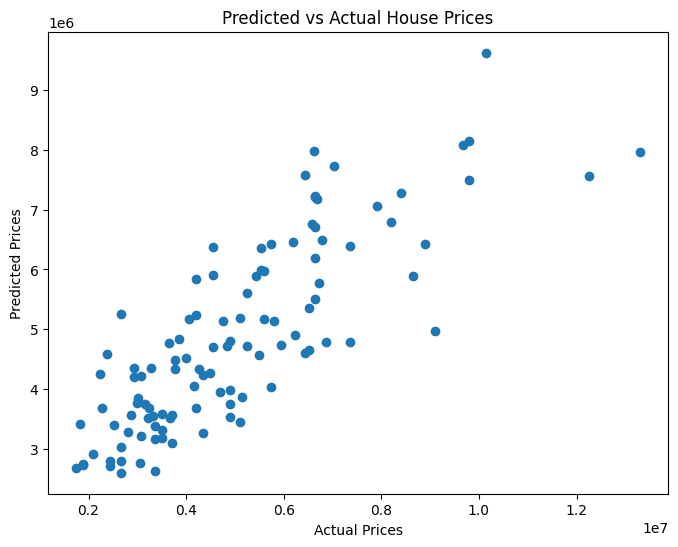

Plot saved


In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Predicted vs Actual House Prices")

plot_path = "/content/drive/MyDrive/Week2_House_Price_Prediction/predicted_vs_actual.png"

plt.savefig(plot_path, bbox_inches="tight")

plt.show()

print("Plot saved")

In [14]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import os

project_folder = "/content/drive/MyDrive/Week2_House_Price_Prediction"

os.makedirs(project_folder, exist_ok=True)

print("Folder ready")

Folder ready


In [17]:
r2 = r2_score(y_test, y_pred)

with open(
    "/content/drive/MyDrive/Week2_House_Price_Prediction/model_results.txt",
    "w"
) as f:

    f.write(f"R2 Score: {r2}")

print("Results saved")

Results saved
